In [1]:
import pandas as pd
from google.colab import files
uploaded = files.upload()

Saving events.xlsx to events (1).xlsx
Saving users.xlsx to users (1).xlsx


In [2]:
import pandas as pd

events1 = pd.read_excel("events.xlsx")
users1 = pd.read_excel("users.xlsx")

events1.head()
users1.head()

,user_id,install_date
0,1,2024-01-07
1,2,2024-01-20
2,3,2024-01-29
3,4,2024-01-15
4,5,2024-01-11


In [3]:
events1.columns
events1.head()

,user_id,event_date,event_type
0,1,2024-01-07,session_start
1,1,2024-01-08,session_start
2,1,2024-01-09,session_start
3,1,2024-01-10,session_start
4,1,2024-01-11,session_start


In [4]:
data = pd.merge(events1, users1, on="user_id")

In [5]:
data["event_date"] = pd.to_datetime(data["event_date"])
data["install_date"] = pd.to_datetime(data["install_date"])

In [6]:
data["days_since_install"] = (data["event_date"] - data["install_date"]).dt.days
data.head()

,user_id,event_date,event_type,install_date,days_since_install
0,1,2024-01-07,session_start,2024-01-07,0
1,1,2024-01-08,session_start,2024-01-07,1
2,1,2024-01-09,session_start,2024-01-07,2
3,1,2024-01-10,session_start,2024-01-07,3
4,1,2024-01-11,session_start,2024-01-07,4


In [7]:
users_total = users1["user_id"].nunique()

retention = data.groupby("days_since_install")["user_id"].nunique() / users_total

retention

,user_id
days_since_install,
0,1.0000
1,0.8188
2,0.6662
3,0.5392
4,0.4406
5,0.3588
6,0.2916
7,0.2422
8,0.2016


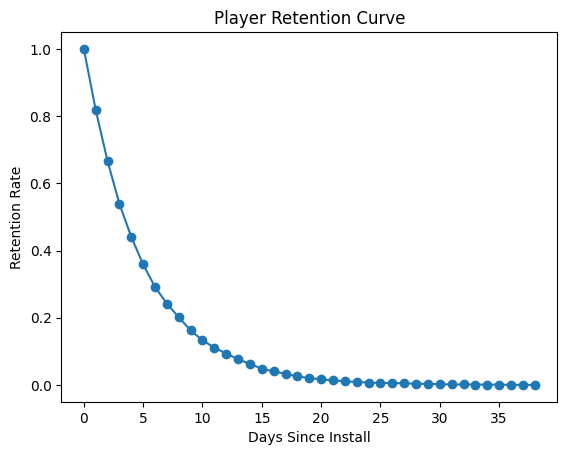

In [8]:
import matplotlib.pyplot as plt

retention.plot(marker='o')
plt.title("Player Retention Curve")
plt.xlabel("Days Since Install")
plt.ylabel("Retention Rate")
plt.show()

In [9]:
last_day = data.groupby("user_id")["days_since_install"].max()
churn = (last_day < 7).mean()
churn

np.float64(0.7578)

In [10]:
active_days = data.groupby("user_id")["days_since_install"].nunique()

active_days.describe()

,days_since_install
count,5000.000000
mean,5.458200
std,4.944729
min,1.000000
25%,2.000000
50%,4.000000
75%,7.000000
max,39.000000


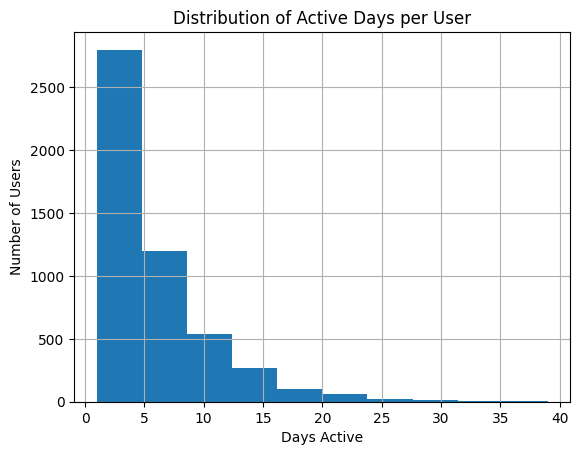

In [11]:
active_days.hist()
plt.title("Distribution of Active Days per User")
plt.xlabel("Days Active")
plt.ylabel("Number of Users")
plt.show()